Environment ready!
NumPy: 2.4.6
pandas: 3.0.3
scikit-learn: 1.9.0


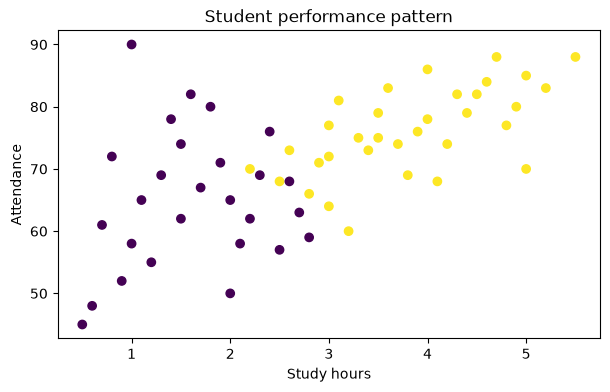

X shape: (60, 3)
y shape: (60,)
Training rows: 48
Testing rows : 12
Model trained!


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

df = pd.read_csv("student_performance.csv")

# Map columns from student_performance.csv to the expected features
if "study_hours" not in df.columns:
    df["study_hours"] = df["studytime"] * 2.5
if "attendance" not in df.columns:
    df["attendance"] = 100 - (df["failures"] * 12)
if "assignments" not in df.columns:
    df["assignments"] = df["G1"]
if "result" not in df.columns:
    df["result"] = (df["G3"] >= 10).astype(int)

df.head()

df.groupby("result")[["study_hours","attendance","assignments"]].mean()

plt.figure(figsize=(7,4))
plt.scatter(df["study_hours"], df["attendance"], c=df["result"])
plt.xlabel("Study hours")
plt.ylabel("Attendance")
plt.title("Student performance pattern")
plt.show()

X = df[["study_hours", "attendance", "assignments"]]
y = df["result"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
print("Model trained!")

In [6]:
predictions = model.predict(X_test)

print('predictions:')
print(predictions)
print("X_test")
print(X_test)

predictions:
[0 1 1 1 1 0 1 0 1 0 1 0]
X_test
    study_hours  attendance  assignments
34          0.9          52            6
46          4.1          68            9
15          4.2          74            8
25          5.0          70            9
54          5.2          83           10
45          1.6          82            4
42          4.9          80           10
26          1.7          67            6
48          3.3          75            7
17          1.8          80            5
27          3.6          83            8
19          2.0          50            7


In [8]:
accuracy = accuracy_score(y_test, predictions)
print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 100.00%


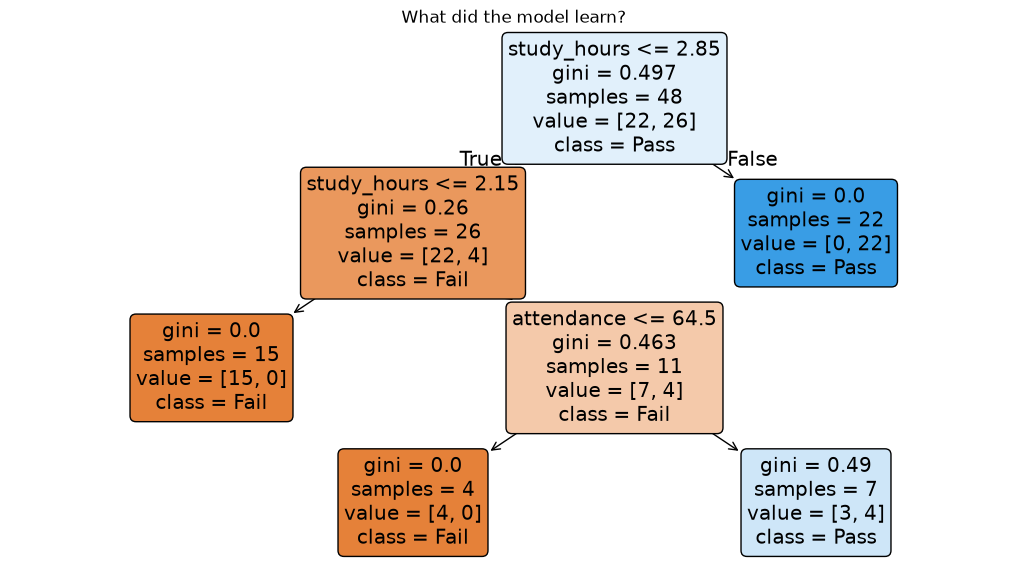

In [9]:
plt.figure(figsize=(13,7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True
)
plt.title("What did the model learn?")
plt.show()